In [101]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [102]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.model_selection import learning_curve
import scipy.stats as stats
from sklearn.linear_model import LinearRegression

In [103]:
data_path = os.path.normpath(os.path.join(os.getcwd(), "data", "placement.csv"))
data = pd.read_csv(data_path)

In [104]:
data.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [105]:
## Data Validation
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   cgpa     200 non-null    float64
 1   package  200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


In [106]:
data.describe()

,cgpa,package
count,200.000000,200.000000
mean,6.990500,2.996050
std,1.069409,0.691644
min,4.260000,1.370000
25%,6.190000,2.487500
50%,6.965000,2.995000
75%,7.737500,3.492500
max,9.580000,4.620000


In [107]:
data.isnull().sum()

cgpa       0
package    0
dtype: int64

In [108]:
data.duplicated().sum()

0

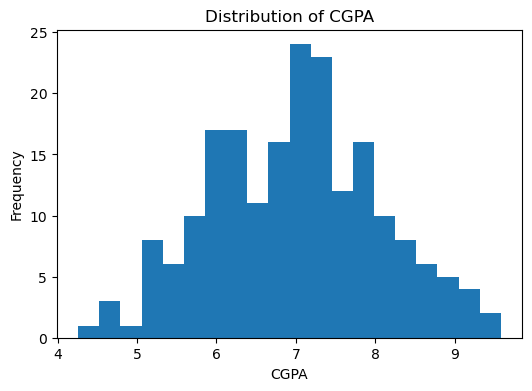

In [109]:
plt.figure(figsize=(6,4))
plt.hist(data["cgpa"], bins=20)
plt.xlabel("CGPA")
plt.ylabel("Frequency")
plt.title("Distribution of CGPA")
plt.show()

In [110]:
print(data.corr())

             cgpa   package
cgpa     1.000000  0.880692
package  0.880692  1.000000


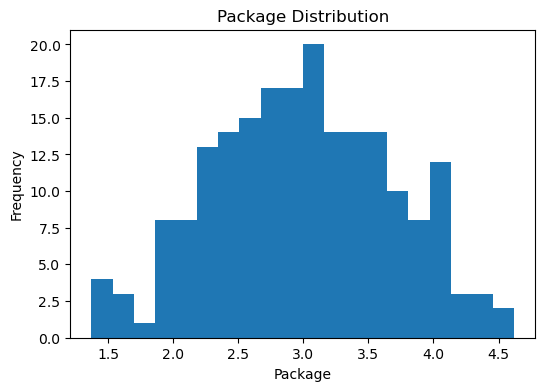

In [111]:
plt.figure(figsize=(6,4))
plt.hist(data["package"], bins=20)
plt.xlabel("Package")
plt.ylabel("Frequency")
plt.title("Package Distribution")
plt.show()

Text(0, 0.5, 'PACKAGE')

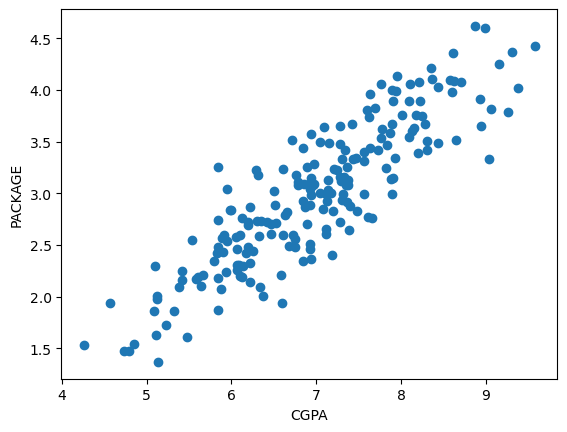

In [112]:
plt.scatter(x=data['cgpa'], y=data['package'])
plt.xlabel("CGPA")
plt.ylabel("PACKAGE")

In [113]:
X = data.iloc[:, 0:1]
y = data.iloc[:, -1]

In [114]:
## Learning Guide

# data.iloc[:, 1].     # Second column (Series)
# data.iloc[:, 0]      # First column (Series)
# data.iloc[:, 0:1]    # First column (DataFrame)
# data.iloc[:, 0:3]    # First three columns
# data.iloc[0:5, :]    # First five rows
# data.iloc[2:10, 1:4] # Rows 2-9, columns 1-3
# data.iloc[:, :-1]    # All columns except the last (features)
# data.iloc[:, -1]     # Last column (target/label)

In [115]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=10, test_size=0.2)

In [116]:
## Dimensions of input data

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

X_train shape: (160, 1)
y_train shape: (160,)


In [117]:
model = LinearRegression()

model.fit(X=X_train, y=y_train)

LinearRegression()

In [118]:
# About the Training Method

# Scikit-learn's LinearRegression uses Ordinary Least Squares (OLS) to fit the regression line.
# It computes the optimal coefficients directly using linear algebra (least squares), rather than iteratively updating them.
# Since it uses a closed-form solution, there are no epochs, learning rate, or batch size involved.
# The objective is to minimize the Residual Sum of Squares (RSS) between the actual and predicted values.
# OLS provides the exact least-squares solution, making it fast and efficient for small to medium-sized datasets.
# If you want to train using Gradient Descent with epochs and visualize the loss curve, use SGDRegressor or implement Linear Regression from scratch.

In [119]:
# Train the linear regression model using the training data.
# The algorithm learns the best-fit line:
# y = mx + b
# where m is the slope and b is the intercept.

predictions = model.predict(X_test)

In [120]:
# Predict for a single value

# model.predict(X_test.iloc[0].values.reshape(1,1)) -

Text(0.5, 1.0, 'Predicted Line Visualiztion')

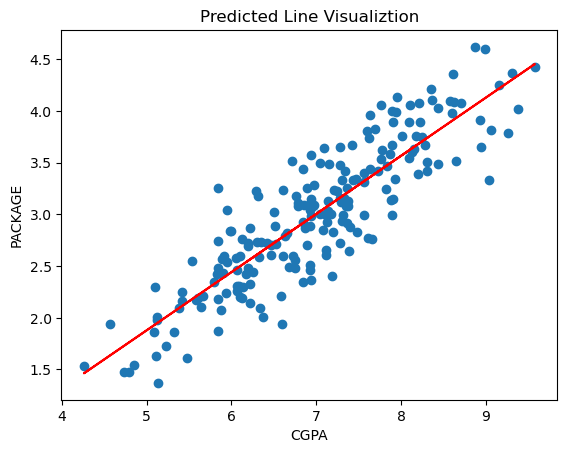

In [121]:
## Predicted Line Visualiztion during training

plt.scatter(x=data['cgpa'], y=data['package'])
plt.plot(X_train, model.predict(X_train), color="red")
plt.xlabel("CGPA")
plt.ylabel("PACKAGE")
plt.title("Predicted Line Visualiztion")

In [122]:
print(model.coef_) # m
print(model.intercept_) # b

[0.5623945]
-0.9329694897307097


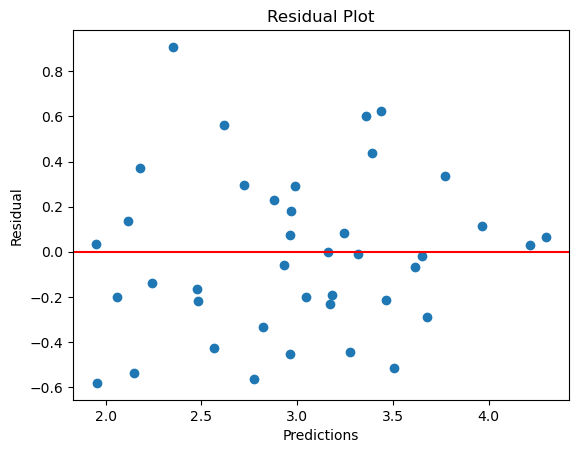

In [123]:
## Residual Plot

pred = model.predict(X_test)

residuals = y_test - pred

plt.scatter(pred, residuals)
plt.axhline(0, color='red')
plt.xlabel("Predictions")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

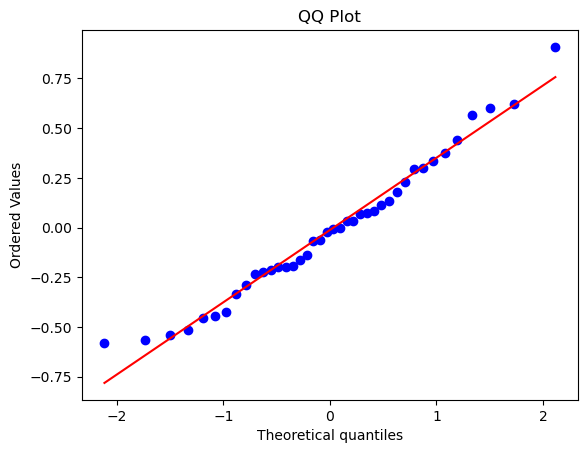

In [124]:
## QQ PLlot - Checks whether residuals are normally distributed.

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ Plot")
plt.show()

In [125]:
# Evaluation metrics

mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred)

print(f"MAE : {mae:.3f}")
print(f"MSE : {mse:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²  : {r2:.3f}")

MAE : 0.281
MSE : 0.124
RMSE: 0.352
R²  : 0.768


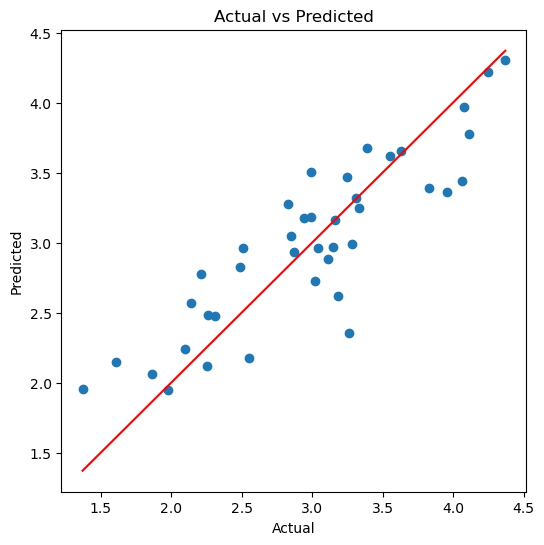

In [126]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.show()

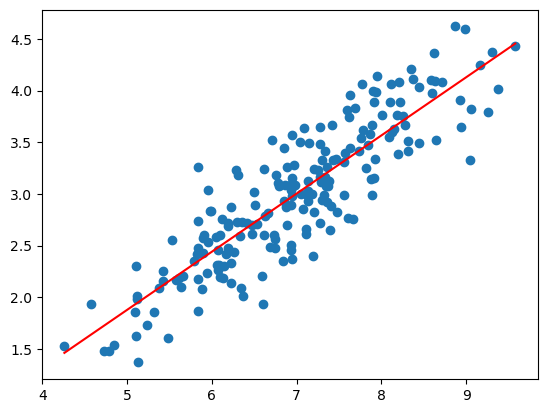

In [127]:
sorted_index = X_train.squeeze().argsort()

plt.scatter(data.cgpa, data.package)

plt.plot(
    X_train.iloc[sorted_index],
    model.predict(X_train.iloc[sorted_index]),
    color='red'
)

plt.show()

In [128]:
# Useful to detect overfitting

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

print("Train R2:", r2_score(y_train, train_pred))
print("Test R2 :", r2_score(y_test, test_pred))

Train R2: 0.7776036912161283
Test R2 : 0.7681105472626018


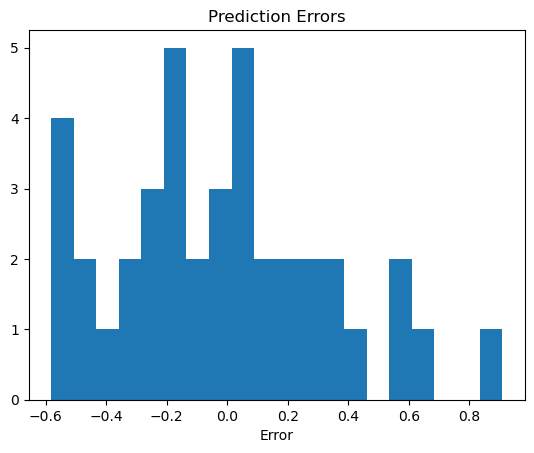

In [129]:
# Error distribution

errors = y_test - pred

plt.hist(errors, bins=20)
plt.title("Prediction Errors")
plt.xlabel("Error")
plt.show()